Ciclo INTERVENSIONISMO ESTATAL ignorado (fuera de rango)


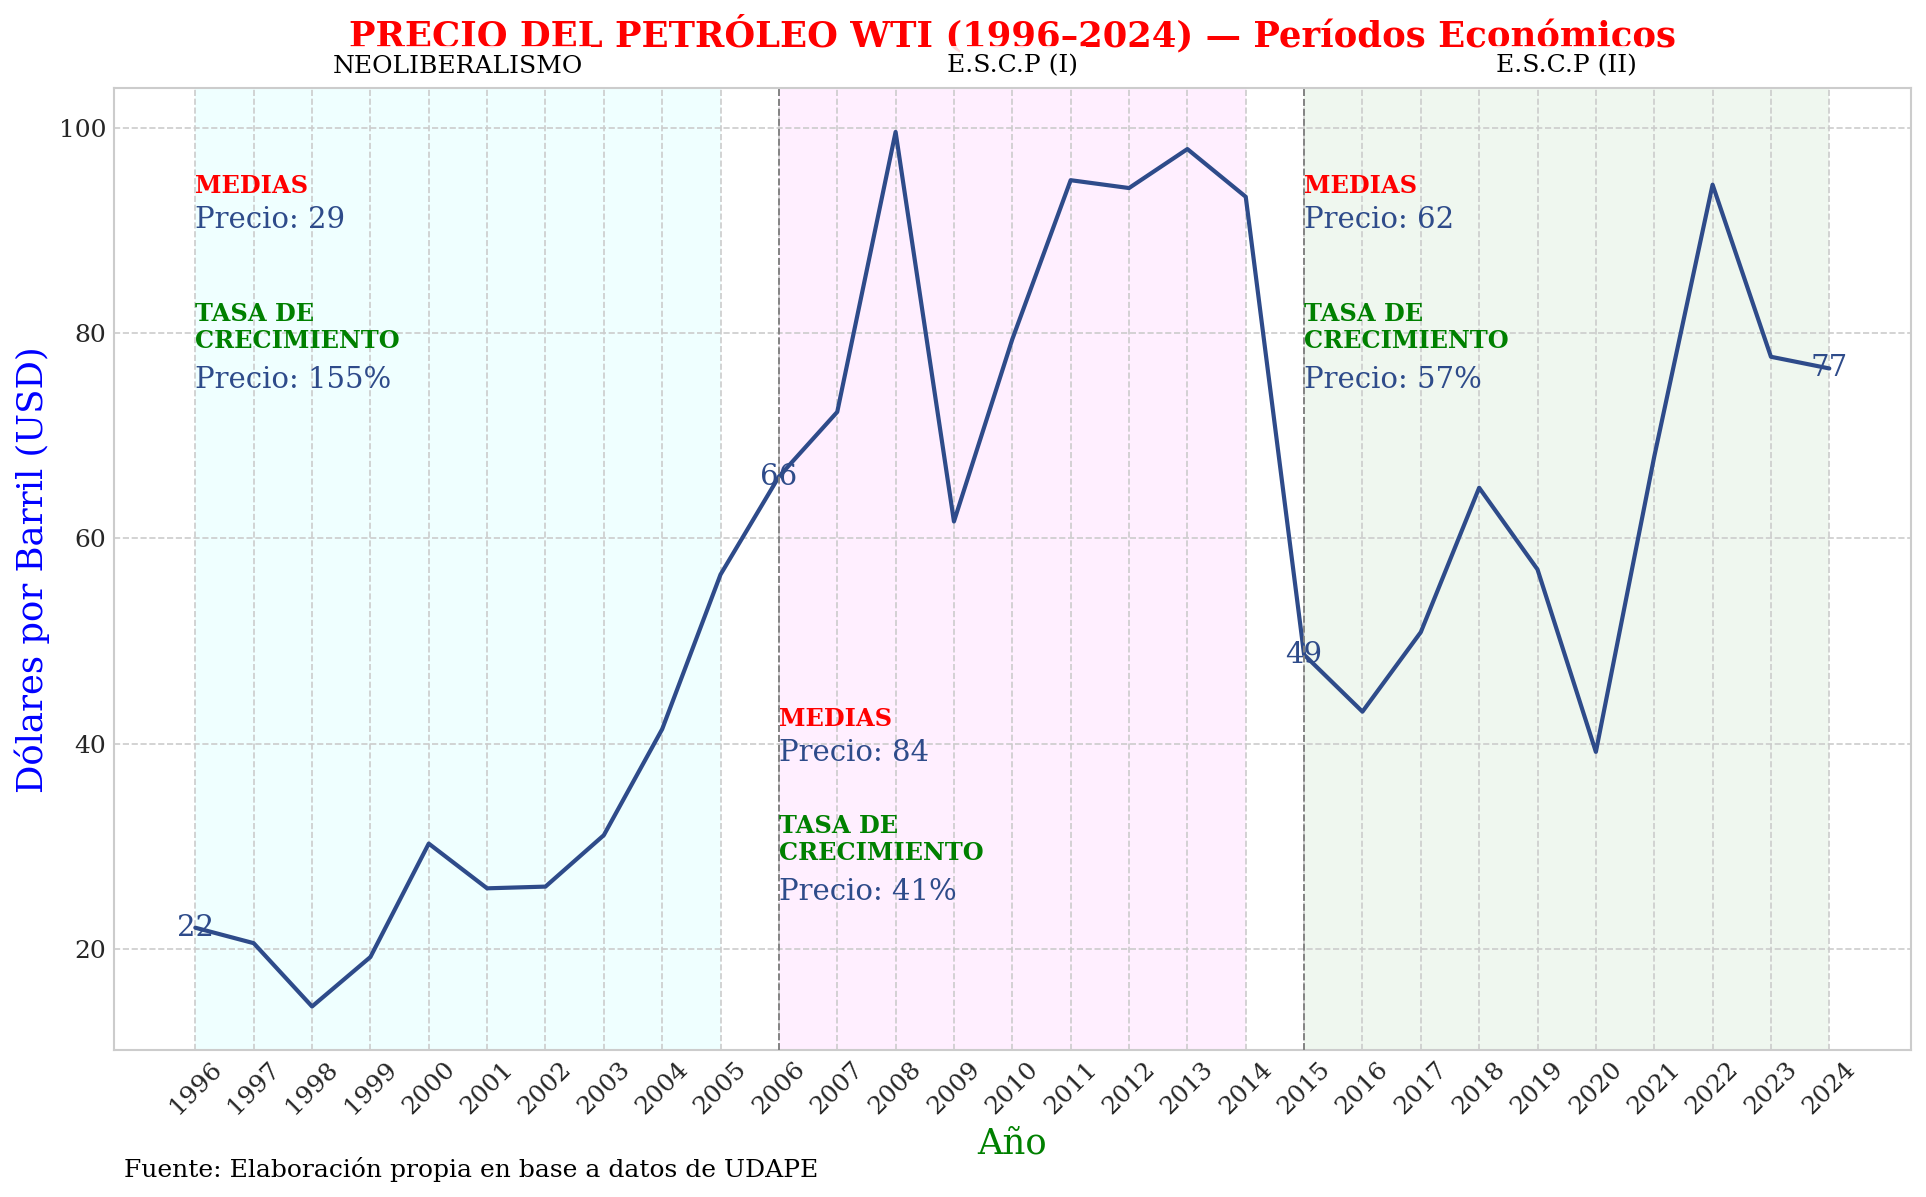

In [1]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA DE PERÍODOS ESTRUCTURALES — PRECIO DEL PETRÓLEO WTI
# ═══════════════════════════════════════════════════════════════════
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ── Raíz del proyecto ────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..')))
from func_auxiliares.graficos_utils import (
    set_style,
    init_base_plot,
    add_hitos,
    add_cycle_means_multi,
    add_year_value_annotations,
    add_period_growth_annotations_multi,
    adjust_annot_years,
    adjust_cycles,
    adjust_periods,
    add_period_backgrounds,
)
from func_auxiliares.config import (
    DB_PATH,
    ASSETS_DIR,
    CYCLES_PERIODOS,
    annot_years_periodos,
    periodos_tasas_periodos,
    hitos_v_periodos,
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR / "serie_completa" / "precio_petroleo_wti"
os.makedirs(output_dir, exist_ok=True)
set_style()

# ─────────────────────────── 2. CARGA DE DATOS ──────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM precio_petroleo_wti",
            conn,
            index_col="año",
        )
        .sort_index()
    )

# ──────────────── 3. COMPONENTES, COLORES Y ABREVIATURAS ────────────
componentes = [
    ("precio", "Precio del Petróleo WTI"),
]
cols_componentes = ["precio"]

colors = {
    "precio": "#2E4B8A",  # Azul petróleo
}
abbr_map = {
    "precio": "Precio",
}

# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ───────────────
annotate_years = adjust_annot_years(df, annot_years_periodos)
cycles         = adjust_cycles(df, CYCLES_PERIODOS)
periods        = adjust_periods(df, periodos_tasas_periodos)

cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}

# ───────────────────── 5. OFFSETS DE POSICIONAMIENTO ────────────────
# Ajustar los valores (x_offset, y_offset) según la escala de la serie
hitos_offset_periodos = {year: 0.85 for year in hitos_v_periodos}

# Anotaciones de valores en años clave
annotation_offsets = {
    "precio": {
        1996: (0, 0),
        2006: (0, 0),
        2015: (0, 0),
        2024: (0, 0),
    }
}

# Posición de medias por período (año_centro, altura_relativa 0-1)
medias_offsets = {
    "INTERVENSIONISMO ESTATAL": (1981, 0.92),
    "NEOLIBERALISMO":           (1996, 0.92),
    "E.S.C.P (I)":              (2006, 0.42),
    "E.S.C.P (II)":             (2015, 0.92),
}

# Posición de tasas de crecimiento (año_centro, altura_relativa 0-1)
tasas_offsets = {
    "1952-1984": (1963, 0.80),
    "1996-2005": (1996, 0.80),
    "2006-2014": (2006, 0.32),
    "2015-2024": (2015, 0.80),
}

# ────────────────────────── 6. GRÁFICO BASE ─────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,
    colors=colors,
    title=f"PRECIO DEL PETRÓLEO WTI ({df.index.min()}\u2013{df.index.max()}) \u2014 Per\u00edodos Econ\u00f3micos",
    xlabel="A\u00f1o",
    ylabel="D\u00f3lares por Barril (USD)",
    source_text="Fuente: Elaboraci\u00f3n propia en base a datos de UDAPE",
)

# ──────────────────── 7. ELEMENTOS GRÁFICOS ─────────────────────────
add_hitos(
    ax,
    df.index,
    hitos_v_periodos,
    hitos_offset_periodos,
    line_kwargs={"lw": 0.9})

add_cycle_means_multi(
    ax, cycle_stats, medias_offsets,
    abbr_map, colors,
    line_spacing=ax.get_ylim()[1] * 0.03,
)

add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.5,
)

add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes, tasas_offsets,
    colors, abbr_map,
)

add_period_backgrounds(
    ax,
    periods,
)

# ────────────────────────── 8. GUARDADO ─────────────────────────────
plt.tight_layout()
fig.savefig(output_dir / "precio_petroleo_wti_periodos.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
